Estimation de l'effet causal de la fermeture des établissement 'social' sur le vote RN à l'aide d'un staggered DID

Import des bibliothèques

In [93]:
import pandas as pd
import polars as pl
import numpy as np
import matplotlib.pyplot as plt
from did_multiplegt_dyn import DidMultiplegtDyn  

Import des données

In [94]:
# Social
df_rnp = pd.read_csv(r"C:\Users\yancr\Documents\ENSAE_V2\STATAPP\V2\STATAPP_V2\Données\Partie Econometrie\communes_social_rnp.csv", index_col=0)
df_rnp['codecommune'] = df_rnp['codecommune'].astype(str).str.zfill(5)

df_rp = pd.read_csv(r"C:\Users\yancr\Documents\ENSAE_V2\STATAPP\V2\STATAPP_V2\Données\Partie Econometrie\communes_social_rp.csv", index_col=0)
df_rp['codecommune'] = df_rp['codecommune'].astype(str).str.zfill(5)

df_ui = pd.read_csv(r"C:\Users\yancr\Documents\ENSAE_V2\STATAPP\V2\STATAPP_V2\Données\Partie Econometrie\communes_social_ui.csv", index_col=0)
df_ui['codecommune'] = df_ui['codecommune'].astype(str).str.zfill(5)

df_ud = pd.read_csv(r"C:\Users\yancr\Documents\ENSAE_V2\STATAPP\V2\STATAPP_V2\Données\Partie Econometrie\communes_social_d.csv", index_col=0)
df_ud['codecommune'] = df_ud['codecommune'].astype(str).str.zfill(5)

C:\Users\yancr\AppData\Local\Temp\ipykernel_30400\2641705729.py:2: DtypeWarning: Columns (0: Annee) have mixed types. Specify dtype option on import or set low_memory=False.
  df_rnp = pd.read_csv(r"C:\Users\yancr\Documents\ENSAE_V2\STATAPP\V2\STATAPP_V2\Données\Partie Econometrie\communes_social_rnp.csv", index_col=0)
C:\Users\yancr\AppData\Local\Temp\ipykernel_30400\2641705729.py:5: DtypeWarning: Columns (0: Annee) have mixed types. Specify dtype option on import or set low_memory=False.
  df_rp = pd.read_csv(r"C:\Users\yancr\Documents\ENSAE_V2\STATAPP\V2\STATAPP_V2\Données\Partie Econometrie\communes_social_rp.csv", index_col=0)
C:\Users\yancr\AppData\Local\Temp\ipykernel_30400\2641705729.py:8: DtypeWarning: Columns (0: Annee) have mixed types. Specify dtype option on import or set low_memory=False.
  df_ui = pd.read_csv(r"C:\Users\yancr\Documents\ENSAE_V2\STATAPP\V2\STATAPP_V2\Données\Partie Econometrie\communes_social_ui.csv", index_col=0)


Fonction d'attribution du traitement

In [227]:
def traitement(df):
    # 1. On définit notre seuil de traitement à partir de l'année 2002
    df_2002 = df[df['Annee'] == 1997].copy()
    df_2002['seuil'] = df_2002['total_equipements'] * 0.66

    # 2. On renseigne ce seuil dans le DataFrame pour comparer les niveaux annuels
    mapping_seuil = df_2002.set_index('codecommune')['seuil']
    df['seuil'] = df['codecommune'].map(mapping_seuil)

    # 3. Première passe : condition simple (1 si on passe sous le seuil, 0 sinon)
    df['traitée'] = (df['total_equipements'] < df['seuil']).astype(int)

    # 4. ÉTAPE CRUCIALE : Trier le tableau pour garantir l'ordre chronologique
    df = df.sort_values(by=['codecommune', 'Annee'])

    # 5. L'EFFET CLIQUET : On applique un maximum cumulé par commune.
    # Dès qu'une commune obtient un 1, toutes les lignes suivantes pour cette commune vaudront 1.
    df['traitée'] = df.groupby('codecommune')['traitée'].cummax()

    return df

In [128]:
1+(12-6)/6

2.0

In [228]:
def traitement_bis(df):
    # 1. On définit notre seuil de référence à partir de l'année 2002
    df_2002 = df[df['Annee'] == 2002]
    
    # 2. On renseigne ce seuil dans le DataFrame pour comparer les niveaux annuels
    mapping_seuil = df_2002.set_index('codecommune')['total_equipements']
    df['seuil'] = df['codecommune'].map(mapping_seuil)
    
    # 3. Calcul du pourcentage restant par rapport à 2002
    # La division directe est plus propre. On multiplie par 100 pour un format lisible.
    df['traitement'] = ((df['total_equipements'] == 0)&(df['total_equipements'] < df['seuil'])&(df['Annee'] >2002)).astype(int)

    df['traitement'] = df['traitement'].replace([float('inf')], 0)
    df['traitement'] = df['traitement'].fillna(0)

    
    # 4. ÉTAPE CRUCIALE : Trier le tableau pour garantir l'ordre chronologique
    df = df.sort_values(by=['codecommune', 'Annee'])
    
    return df

## Calcul du traitement

### RNP

In [230]:
df_rnp = traitement(df_rnp)

### RP

In [201]:
df_rp = traitement_bis(df_rp)

### UI

In [98]:
df_ui = traitement(df_ui)

### UD

In [99]:
df_ud = traitement(df_ud)

## DID

In [199]:
df_rnp[(df_rnp['traitement']==1)&(df_rnp['Annee']==2022)]

,codecommune,Annee,pop,propf,prop014,prop1539,prop4059,prop60p,petranger,pcapi,...,vote_EG_pres,abstention_pres,vote_RN_pres,vote_EG_leg,abstention_leg,vote_RN_leg,total_equipements,seuil,traitée,traitement
111,01012,2022,331,0.473945,0.275434,0.285360,0.059553,0.379653,0.014749,0.000000,...,0.335455,0.219081,0.245455,0.363314,0.399306,0.147929,0.0,2.0,1,1
195,01017,2022,475,0.626126,0.218468,0.135135,0.288288,0.358108,0.019737,0.000000,...,0.285490,0.149351,0.349020,0.318436,0.415335,0.340782,0.0,1.0,1,1
251,01028,2022,636,0.647564,0.128940,0.419771,0.153295,0.297994,0.004724,0.404255,...,0.146552,0.180556,0.333333,0.122066,0.506881,0.314554,0.0,1.0,1,1
307,01037,2022,324,0.518634,0.133540,0.164596,0.307453,0.394410,0.054313,0.369231,...,0.206704,0.240816,0.273743,0.232000,0.473469,0.224000,0.0,1.0,1,1
447,01060,2022,459,0.409449,0.157480,0.244094,0.364173,0.234252,0.012320,0.453704,...,0.215385,0.178733,0.230769,0.200000,0.435080,0.080169,0.0,2.0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
330007,89452,2022,373,0.517483,0.142191,0.421911,0.149184,0.286713,0.016867,0.222973,...,0.181897,0.207921,0.344828,0.211180,0.440000,0.440994,0.0,3.0,1,1
330035,89462,2022,300,0.509434,0.113208,0.086792,0.245283,0.554717,0.014870,0.285714,...,0.231395,0.218182,0.319767,0.302326,0.409910,0.248062,0.0,1.0,1,1
330259,90014,2022,508,0.533981,0.132039,0.161165,0.448544,0.258252,0.043137,0.493243,...,0.130112,0.236413,0.401487,0.226027,0.593496,0.287671,0.0,1.0,1,1
330371,90043,2022,595,0.443381,0.204147,0.296651,0.287081,0.212121,0.029557,0.333333,...,0.182445,0.257403,0.404389,0.165919,0.485327,0.340807,0.0,2.0,1,1


Definition du modele

In [237]:
def DID (df) :
    # 1. On filtre la base pour ne garder que les années d'élection présidentielle
    annees_pres = [1995, 2002, 2007, 2012, 2017, 2022]
    df_pres = df[df['Annee'].isin(annees_pres)].copy()

    # 2. Nettoyage : on retire les lignes avec des valeurs manquantes essentielles
    df_pres = df_pres.dropna(subset=['vote_RN_pres', 'traitée'])

    # 3. On force les types en formats "simples" (Numpy) pour faciliter la conversion
    # (Cela vous évite l'erreur PyArrow)
    df_pres['vote_RN_pres'] = df_pres['vote_RN_pres'].astype('float64')
    df_pres['traitée'] = df_pres['traitée'].astype('float64')
    df_pres['Annee'] = df_pres['Annee'].astype('int64')
    # Note : S'il y a un souci avec 'codecommune' (par exemple si c'est un format 'object'),
    # vous pouvez aussi le forcer en string classique : df_pres['codecommune'] = df_pres['codecommune'].astype('str')

    # 4. Conversion en Polars
    df_pres_polars = pl.from_pandas(df_pres)

    # 5. Estimation Staggered DiD (avec le nom de classe corrigé)
    modele_did = DidMultiplegtDyn(
        df=df_pres_polars,         
        outcome='vote_RN_pres',    # Variable dépendante
        group='codecommune',       # Identifiant du groupe
        time='Annee',              # Variable temporelle
        treatment='traitée',       # Indicateur de traitement
        placebo=2,                 # Tester 1 période avant le traitement (pre-trends)
        effects=5,                 # Estimer l'effet sur les 2 périodes suivant le traitement
        cluster='codecommune',      # Clustering des erreurs-types
        controls = ['pop', 'propf', 'prop014', 'prop1539', 'prop60p', 'petranger', 'pouem', 'pchom', 'paind','pbac', 'psup', 'revmoy']
    )

    modele_did.fit()
    modele_did.summary()
    modele_did.plot()
    return 

### RNP

             Estimation of treatment effects: Event-study effects
               Block  Estimate       SE     LB CI    UB CI       N  Switchers     N.w  Switchers.w
            Effect_1  0.000556 0.000690 -0.000796 0.001908 38420.0     5033.0 38420.0       5033.0
            Effect_2  0.003847 0.000912  0.002059 0.005635 29067.0     4500.0 29067.0       4500.0
            Effect_3  0.007501 0.001222  0.005106 0.009895 21063.0     3884.0 21063.0       3884.0
            Effect_4  0.011586 0.001643  0.008365 0.014807 13669.0     2882.0 13669.0       2882.0
            Effect_5  0.012861 0.002421  0.008116 0.017607  6462.0     1446.0  6462.0       1446.0
Average_Total_Effect  0.005705 0.000924  0.003894 0.007515 51152.0    17745.0 51152.0      17745.0
           Placebo_1  0.000270 0.000786 -0.001271 0.001812 28090.0     3542.0 28090.0       3542.0
           Placebo_2 -0.001080 0.001340 -0.003706 0.001546 12369.0     1593.0 12369.0       1593.0
Test of joint nullity of the effects: p-val

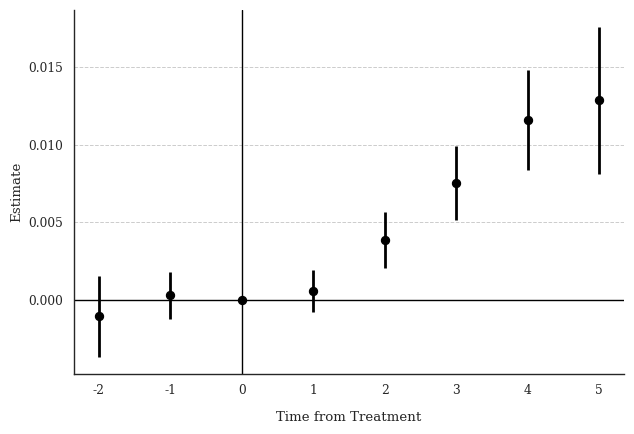

In [238]:
DID(df_rnp)

In [240]:
import scipy.stats as st

# Les valeurs de votre test Placebo
estimate_placebo = 0.006144 
se_placebo =   0.005294

# 1. Calcul du Z-score
z_score = estimate_placebo / se_placebo

# 2. Calcul de la p-value bilatérale
p_value = 2 * (1 - st.norm.cdf(abs(z_score)))

print(f"Z-score : {z_score:.3f}")
print(f"P-value du Placebo : {p_value:.3f}")

Z-score : 1.161
P-value du Placebo : 0.246


### RP

In [246]:
df_rnp['codecommune'][(df_rnp['traitée']==1)&(df_rnp['Annee']<2002)].unique()

<ArrowStringArray>
['01007', '01012', '01017', '01028', '01037', '01066', '01067', '01118',
 '01133', '01191',
 ...
 '89391', '89398', '89407', '89412', '89423', '89433', '89462', '89485',
 '90014', '90078']
Length: 2546, dtype: str

In [247]:
df_rp['codecommune'][(df_rp['traitée']==1)&(df_rp['Annee']<2002)].unique()

<ArrowStringArray>
['01011', '01029', '01045', '01054', '01085', '01106', '01115', '01130',
 '01147', '01151',
 ...
 '91435', '95002', '95040', '95287', '95365', '95379', '95459', '95483',
 '95527', '95584']
Length: 1496, dtype: str

             Estimation of treatment effects: Event-study effects
               Block  Estimate       SE     LB CI    UB CI       N  Switchers     N.w  Switchers.w
            Effect_1  0.002359 0.000803  0.000786 0.003932 42735.0     3143.0 42735.0       3143.0
            Effect_2  0.004601 0.001113  0.002419 0.006783 32626.0     2598.0 32626.0       2598.0
            Effect_3  0.006026 0.001518  0.003050 0.009001 23437.0     1984.0 23437.0       1984.0
            Effect_4  0.007032 0.002361  0.002405 0.011659 14857.0     1180.0 14857.0       1180.0
            Effect_5  0.006144 0.005294 -0.004232 0.016520  6708.0      186.0  6708.0        186.0
Average_Total_Effect  0.004484 0.001068  0.002391 0.006577 48695.0     9091.0 48695.0       9091.0
           Placebo_1  0.000361 0.000810 -0.001227 0.001948 32960.0     2943.0 32960.0       2943.0
           Placebo_2 -0.002721 0.001394 -0.005454 0.000013 15077.0     1403.0 15077.0       1403.0
Test of joint nullity of the effects: p-val

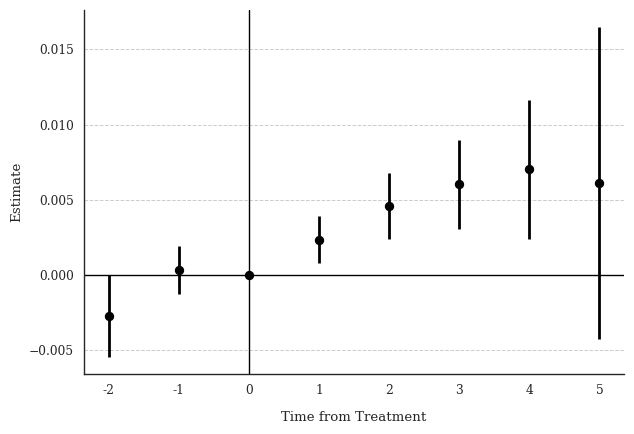

In [239]:
DID(df_rp)

### UI

             Estimation of treatment effects: Event-study effects
               Block  Estimate       SE     LB CI     UB CI       N  Switchers     N.w  Switchers.w
            Effect_1  0.007079 0.001196  0.004735  0.009422 14429.0      777.0 14429.0        777.0
            Effect_2  0.012245 0.001896  0.008529  0.015962 11183.0      651.0 11183.0        651.0
            Effect_3  0.008693 0.002757  0.003290  0.014096  8090.0      480.0  8090.0        480.0
            Effect_4  0.003438 0.004454 -0.005292  0.012168  5170.0      252.0  5170.0        252.0
            Effect_5 -0.001056 0.010670 -0.021969  0.019857  2449.0       52.0  2449.0         52.0
Average_Total_Effect  0.008344 0.001839  0.004739  0.011948 15866.0     2212.0 15866.0       2212.0
           Placebo_1 -0.003890 0.001267 -0.006373 -0.001407 11255.0      725.0 11255.0        725.0
           Placebo_2 -0.009299 0.002277 -0.013763 -0.004836  5317.0      399.0  5317.0        399.0
Test of joint nullity of the effec

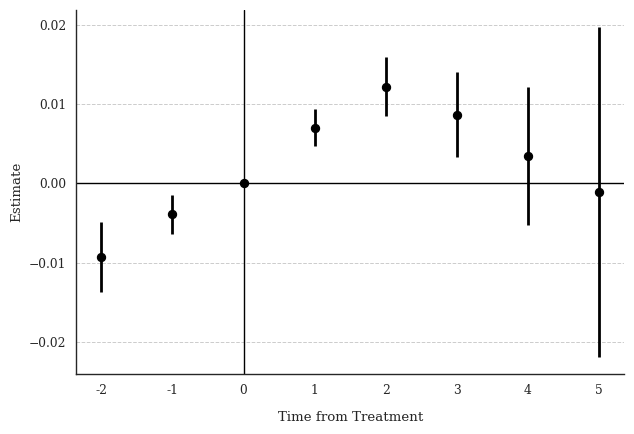

In [248]:
DID(df_ui)

### UD

             Estimation of treatment effects: Event-study effects
               Block  Estimate       SE     LB CI     UB CI      N  Switchers    N.w  Switchers.w
            Effect_1  0.011353 0.003813  0.003880  0.018826 3349.0       69.0 3349.0         69.0
            Effect_2  0.025715 0.006235  0.013495  0.037935 2648.0       61.0 2648.0         61.0
            Effect_3  0.023263 0.008981  0.005662  0.040865 1949.0       38.0 1949.0         38.0
            Effect_4 -0.003998 0.010051 -0.023697  0.015701 1273.0       17.0 1273.0         17.0
            Effect_5  0.024026 0.024116 -0.023241  0.071293  625.0        1.0  625.0          1.0
Average_Total_Effect  0.017162 0.004975  0.007411  0.026912 3466.0      186.0 3466.0        186.0
           Placebo_1 -0.014342 0.003426 -0.021056 -0.007628 2655.0       68.0 2655.0         68.0
           Placebo_2 -0.018334 0.006186 -0.030457 -0.006210 1300.0       44.0 1300.0         44.0
Test of joint nullity of the effects: p-value = 0.00

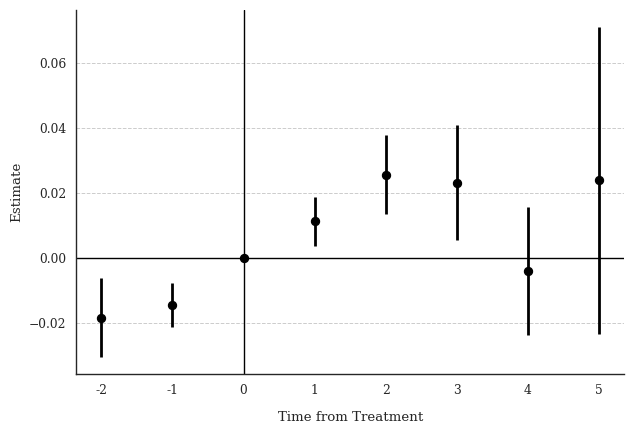

In [249]:
DID(df_ud)